# 06 · Topographic organization metric

Nearby sites in cortex tend to respond similarly. This metric asks the same of a
model: are units that sit near each other in the model's spatial layout more
correlated than distant ones? It scores *organization*, not predictivity
(TDANN / TopoLM style).

Synthetic maps here: a **topographic** layout (smooth over 2-D positions) and a
**random** layout (no spatial structure).

## Two toy layouts

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
from scipy.ndimage import gaussian_filter
from brainscore.metrics.topographic import (spatial_smoothness,
    correlation_distance_profile, topographic_alignment)

# Build the two synthetic layouts we score below: each is a set of unit responses
# plus a fixed 2-D grid position for every unit.
def grid_pos(g):
    '''Return normalized (row, col) coordinates for a g x g grid of units, one row per unit.'''
    r, c = np.meshgrid(np.arange(g), np.arange(g), indexing='ij')
    return np.stack([r.ravel(), c.ravel()], -1) / (g - 1)

def topographic(n=60, g=16, seed=0, sig=2.0):
    '''"Brain-like" layout: n maps that vary smoothly over the g x g grid, so nearby units respond alike.'''
    rng = np.random.RandomState(seed)
    R = np.stack([gaussian_filter(rng.randn(g, g), sig, mode='reflect').ravel()
                  for _ in range(n)])          # local smoothing -> spatial structure
    return R, grid_pos(g)

def random_layout(n=60, g=16, seed=0):
    '''Control layout: n units of pure noise on the same grid, so position carries no information.'''
    return np.random.RandomState(seed).randn(n, g * g), grid_pos(g)

## Spatial smoothness

Smoothness = how strongly response similarity tracks spatial proximity: ~0 for a random layout, positive when nearby units are more alike.

In [2]:
# Make one of each layout, then score how strongly response similarity tracks spatial proximity.
tr, tp = topographic(); rr, rp = random_layout()
print('topographic smoothness:', round(spatial_smoothness(tr, tp), 3), ' (positive -> organized)')
print('random smoothness:     ', round(spatial_smoothness(rr, rp), 3), ' (~0 -> no structure)')

topographic smoothness: 0.649  (positive -> organized)
random smoothness:      -0.004  (~0 -> no structure)


## Correlation-vs-distance profile

For a topographic layout, correlation should be high for nearby units and **decay monotonically** with distance. Random stays flat near zero.

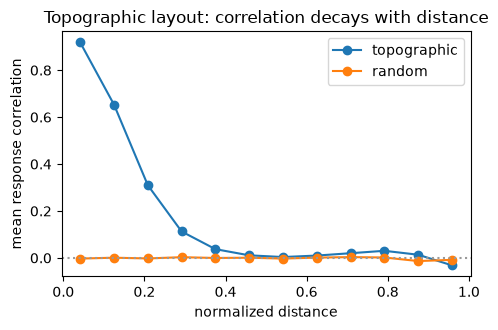

In [3]:
import matplotlib.pyplot as plt
# For each layout, bin unit pairs by distance and average their response correlation in each bin.
cx, cy, _ = correlation_distance_profile(tr, tp, n_bins=12)
rx, ry, _ = correlation_distance_profile(rr, rp, n_bins=12)
# Topographic profile should start high and decay with distance; random stays flat near zero.
fig, ax = plt.subplots(figsize=(5, 3.4))
ax.plot(cx, cy, '-o', label='topographic')
ax.plot(rx, ry, '-o', label='random')
ax.axhline(0, ls=':', c='0.6')
ax.set_xlabel('normalized distance'); ax.set_ylabel('mean response correlation')
ax.set_title('Topographic layout: correlation decays with distance'); ax.legend()
fig.tight_layout(); plt.show()

## Alignment to a target 'brain'

`topographic_alignment` correlates a model's profile with a target's. Here the target is another topographic map (a stand-in for cortex); a topographic model matches it, a random model does not.

In [4]:
brain, bp = topographic(seed=1)                 # target with spatial structure
# Compare each model's correlation-vs-distance profile to the target's; higher = better-matched organization.
align_topo = topographic_alignment(tr, tp, brain, bp, n_bins=12)[0]
align_rand = topographic_alignment(rr, rp, brain, bp, n_bins=12)[0]
print(f'topographic model vs target: {float(align_topo):.3f}')
print(f'random model vs target:      {float(align_rand):.3f}')
print('topographic aligns more:', float(align_topo) > float(align_rand))

topographic model vs target: 0.996
random model vs target:      0.086
topographic aligns more: True


**Reading it:** the topographic layout has a smooth, decaying correlation-vs-distance
profile that matches the target, so its alignment score is high; the random layout
is flat and near zero. On real data the target profile comes from voxel surface
coordinates and `TopographicMetric` scores the model the same way.